In [17]:
# NOTEBOOK: Clustering Results Analysis
# Run this after: python src/cluster.py --full


import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)


# CELL 1: Load Clustering Results


clustering_file = Path("../outputs/02_clustering_results.json")
insights_file = Path("../outputs/02_insights.json")
evaluation_file = Path("../outputs/02_clustering_evaluation.json")

with open(clustering_file) as f:
    clustering_data = json.load(f)

with open(insights_file) as f:
    insights_data = json.load(f)

with open(evaluation_file) as f:
    evaluation_data = json.load(f)

print("CLUSTERING RESULTS OVERVIEW")

# Get metadata from clustering_data, timestamp from evaluation_data
clustering_metadata = clustering_data['metadata']
evaluation_metadata = evaluation_data

print(f"\nTimestamp: {evaluation_metadata['timestamp']}")
print(f"Clustering Method: {clustering_metadata['method']}")
print(f"Number of Clusters: {clustering_metadata['n_clusters']}")

CLUSTERING RESULTS OVERVIEW

Timestamp: 2026-07-12T13:58:34.187616
Clustering Method: kmeans
Number of Clusters: 38


In [14]:
# CELL 2: Clustering Quality Metrics

print(f"CLUSTERING QUALITY METRICS")

metrics = clustering_metadata
print(f"Silhouette Score: {metrics.get('silhouette_score', 'N/A'):.4f}")
print(f"Davies-Bouldin Score: {metrics.get('davies_bouldin_score', 'N/A'):.4f}")

# Interpretation
silhouette = metrics.get('silhouette_score', 0)
if silhouette > 0.5:
    quality = "Excellent"
elif silhouette > 0.3:
    quality = "Good"
elif silhouette > 0.1:
    quality = "Fair"
else:
    quality = "Poor"

print(f"\nCluster Quality Assessment: {quality}")

CLUSTERING QUALITY METRICS
Silhouette Score: 0.0657
Davies-Bouldin Score: 3.1604

Cluster Quality Assessment: Poor


CLUSTER SIZE DISTRIBUTION
Min........................... 102.00
Max........................... 752.00
Mean.......................... 254.50
Median........................ 213.00


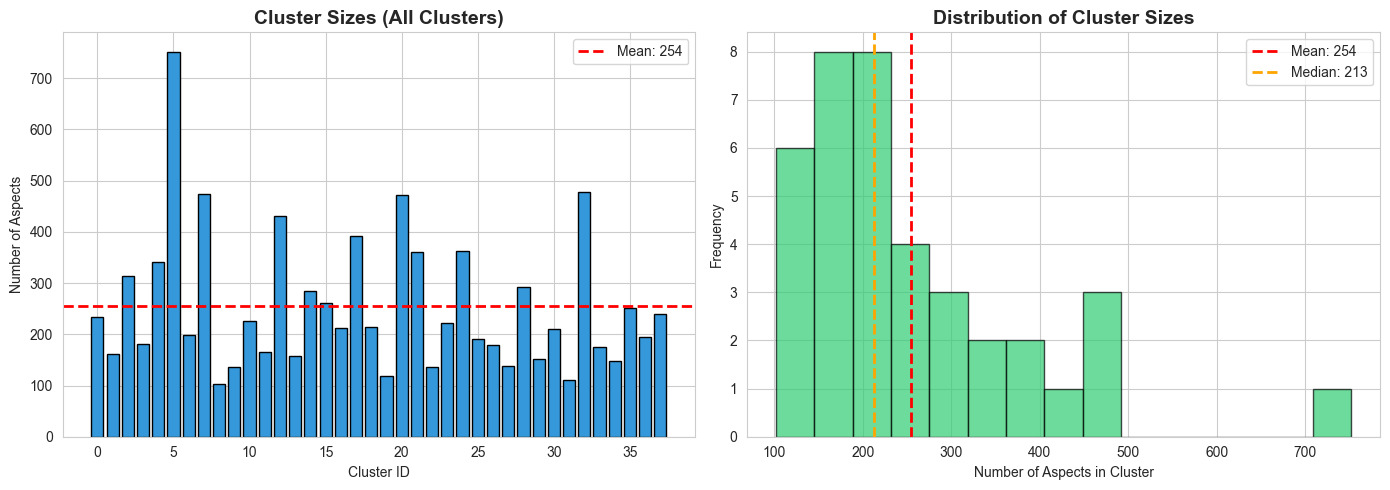

In [16]:
# CELL 3: Cluster Size Distribution

print(f"CLUSTER SIZE DISTRIBUTION")

cluster_stats = evaluation_data['cluster_statistics']
cluster_sizes_dict = cluster_stats['cluster_sizes']

size_stats = {
    'Min': cluster_sizes_dict['min'],
    'Max': cluster_sizes_dict['max'],
    'Mean': cluster_sizes_dict['mean'],
    'Median': cluster_sizes_dict['median'],
}

for stat, value in size_stats.items():
    print(f"{stat:.<30} {value:.2f}")

# Get actual cluster sizes
actual_sizes = [len(cluster) for cluster in clustering_data['clusters'].values()]

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of cluster sizes
cluster_ids = list(range(len(actual_sizes)))
axes[0].bar(cluster_ids, actual_sizes, color='#3498db', edgecolor='black')
axes[0].axhline(np.mean(actual_sizes), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {np.mean(actual_sizes):.0f}')
axes[0].set_title('Cluster Sizes (All Clusters)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cluster ID')
axes[0].set_ylabel('Number of Aspects')
axes[0].legend()

# Histogram of cluster sizes
axes[1].hist(actual_sizes, bins=15, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[1].axvline(np.mean(actual_sizes), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {np.mean(actual_sizes):.0f}')
axes[1].axvline(np.median(actual_sizes), color='orange', linestyle='--', linewidth=2, 
                label=f'Median: {np.median(actual_sizes):.0f}')
axes[1].set_title('Distribution of Cluster Sizes', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Aspects in Cluster')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# CELL 4: Insights Overview

print(f"GENERATED INSIGHTS OVERVIEW")

print(f"\nTotal clusters with insights: {len(insights_data)}")
print(f"\nCluster Names (first 20):")
for i, (cluster_id, insight) in enumerate(sorted(insights_data.items(), 
                                                  key=lambda x: int(x[0]))[:20]):
    cluster_name = insight.get('cluster_name', 'Unknown')
    sentiment = insight.get('primary_sentiment', 'Unknown')
    print(f"  Cluster {cluster_id:2s}: {cluster_name:.<40} ({sentiment})")

GENERATED INSIGHTS OVERVIEW

Total clusters with insights: 38

Cluster Names (first 20):
  Cluster 0 : Fee Structure Transparency.............. (mixed)
  Cluster 1 : Digital Access Paradox.................. (mixed)
  Cluster 2 : Update Quality & Stability Crisis....... (negative)
  Cluster 3 : App Experience Paradox.................. (mixed)
  Cluster 4 : Spending Tracking & Analytics........... (positive)
  Cluster 5 : Service Delivery Paradox................ (mixed)
  Cluster 6 : Process Friction & Complexity........... (negative)
  Cluster 7 : Security vs. Usability Gap.............. (mixed)
  Cluster 8 : Fund Access Friction.................... (mixed)
  Cluster 9 : Lending Operations & Transparency....... (mixed)
  Cluster 10: Service Quality Paradox................. (mixed)
  Cluster 11: Service Delivery Gaps................... (mixed)
  Cluster 12: Session Management Instability.......... (negative)
  Cluster 13: Reliability & Stability................. (mixed)
  Cluster 14: Pay

SENTIMENT DISTRIBUTION IN CLUSTERS

Overall Sentiment Distribution:
Sentiment  Count
 negative   4902
 positive   4570
  neutral    198
    mixed      1


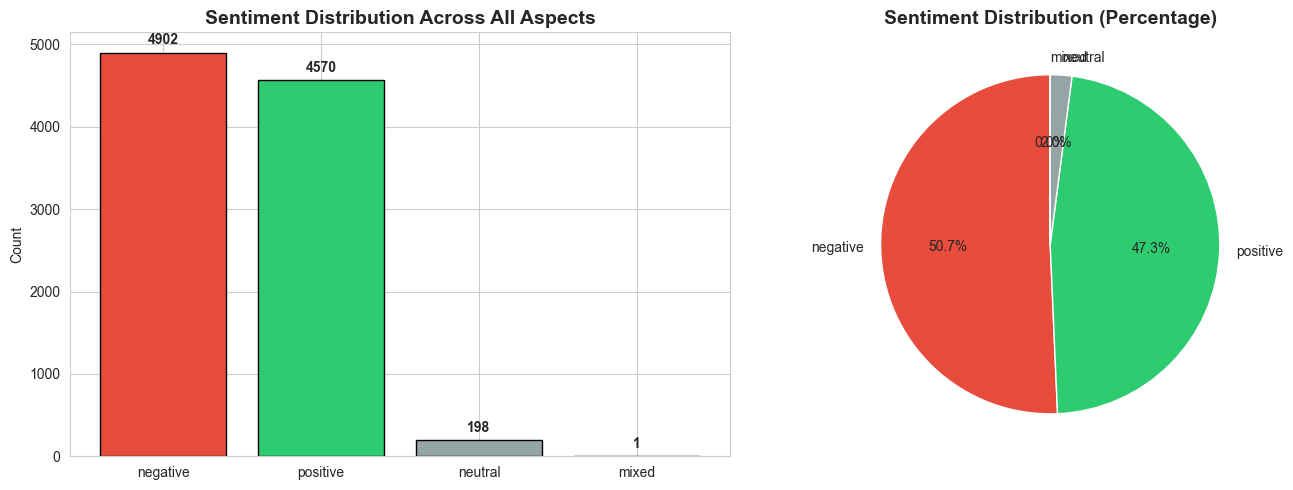

In [20]:
# CELL 5: Sentiment Distribution Across Clusters

print(f"SENTIMENT DISTRIBUTION IN CLUSTERS")

sentiment_dist = evaluation_data['sentiment_distribution']

# Flatten sentiment distribution
all_sentiments = []
for cluster_id, sentiments in sentiment_dist.items():
    for sentiment, count in sentiments.items():
        all_sentiments.extend([sentiment] * count)

sentiment_counts = Counter(all_sentiments)
sentiment_df = pd.DataFrame([
    {'Sentiment': sent, 'Count': count}
    for sent, count in sentiment_counts.items()
])
sentiment_df = sentiment_df.sort_values('Count', ascending=False)

print("\nOverall Sentiment Distribution:")
print(sentiment_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#95a5a6'}
sentiment_colors = [colors.get(s, '#95a5a6') for s in sentiment_df['Sentiment']]

axes[0].bar(sentiment_df['Sentiment'], sentiment_df['Count'], color=sentiment_colors, edgecolor='black')
axes[0].set_title('Sentiment Distribution Across All Aspects', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(sentiment_df['Count']):
    axes[0].text(i, v + 100, str(int(v)), ha='center', fontweight='bold')

axes[1].pie(sentiment_df['Count'], labels=sentiment_df['Sentiment'], autopct='%1.1f%%',
            colors=sentiment_colors, startangle=90)
axes[1].set_title('Sentiment Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [26]:
# CELL 6: Cluster Themes and Summaries (Sample)

print(f"CLUSTER INSIGHTS (Sample - First 5)")

for cluster_id in sorted([int(k) for k in insights_data.keys()])[:5]:
    cluster_id_str = str(cluster_id)
    insight = insights_data[cluster_id_str]
    print("\n")
    print(f"CLUSTER {cluster_id}: {insight['cluster_name'].upper()}\n")
    print(f"Summary: {insight['summary']}")
    print(f"Sentiment: {insight['primary_sentiment']}")
    print(f"Key Themes:")
    for theme in insight['key_themes']:
        print(f"  • {theme}")
    if insight.get('business_impact'):
        print(f"Business Impact: {insight['business_impact']}")

CLUSTER INSIGHTS (Sample - First 5)


CLUSTER 0: FEE STRUCTURE TRANSPARENCY

Summary: Customers have strong, divergent opinions on banking fees and pricing structures, with widespread appreciation for transparent, competitive fee models but significant frustration with hidden charges, unfair overdraft practices, and premium subscription costs. This reflects a core tension between satisfaction with baseline transaction fees and dissatisfaction with opaque or punitive fee structures.
Sentiment: mixed
Key Themes:
  • Transparency gap: Customers praise fee clarity but criticize hidden charges, unexpected billing, and insufficient communication about actual costs
  • Fee fairness disparity: Strong positive sentiment on standard transaction and international fees contrasts sharply with negative views on overdraft rates, premium memberships, and specialized service charges
  • Competitive cost positioning: Customers value cost savings vs. competitors and no-fee offerings, but resent being cha

In [41]:

# ANALYZE LARGE CLUSTER (Cluster 36 - 752 aspects)

import json
import pandas as pd
from pathlib import Path
from collections import Counter

clustering_file = Path("../outputs/02_clustering_results.json")
insights_file = Path("../outputs/02_insights.json")

with open(clustering_file) as f:
    clustering_data = json.load(f)

with open(insights_file) as f:
    insights_data = json.load(f)

# Get cluster 36
cluster_36_aspects = clustering_data['clusters']['36']
insight_36 = insights_data['36']

print("CLUSTER 36: LARGE CLUSTER ANALYSIS")

# Basic stats
print(f"\n📊 Cluster Size: {len(cluster_36_aspects)} aspects")
print(f"\nCluster Name: {insight_36['cluster_name']}")
print(f"Summary: {insight_36['summary']}")
print(f"Primary Sentiment: {insight_36['primary_sentiment']}")

# Sentiment breakdown
sentiments = Counter([a['sentiment'] for a in cluster_36_aspects])
print(f"\n📈 Sentiment Distribution:")
for sentiment, count in sentiments.most_common():
    pct = count / len(cluster_36_aspects) * 100
    print(f"   {sentiment:.<20} {count:4d} ({pct:5.1f}%)")

# Confidence distribution
confidences = [a['confidence'] for a in cluster_36_aspects]
print(f"\n🎯 Confidence Score Distribution:")
print(f"   Mean:   {sum(confidences)/len(confidences):.4f}")
print(f"   Min:    {min(confidences):.4f}")
print(f"   Max:    {max(confidences):.4f}")
print(f"   Median: {sorted(confidences)[len(confidences)//2]:.4f}")

# Top aspects in this cluster
print(f"\n🏆 Top 30 Aspects in Cluster 36 (by frequency):")
aspect_counts = Counter([a['aspect'] for a in cluster_37_aspects])
for i, (aspect, count) in enumerate(aspect_counts.most_common(30), 1):
    print(f"   {i:2d}. {aspect:.<50} (appears {count} times)")

# Sentiment by top aspects
print(f"\n💭 Sentiment for Top 10 Aspects:")
top_aspects = [a[0] for a in aspect_counts.most_common(10)]

for aspect in top_aspects:
    aspect_items = [a for a in cluster_36_aspects if a['aspect'] == aspect]
    sentiments_for_aspect = Counter([a['sentiment'] for a in aspect_items])
    
    print(f"\n   {aspect}")
    for sentiment, count in sentiments_for_aspect.most_common():
        pct = count / len(aspect_items) * 100
        print(f"      {sentiment}: {count:2d} ({pct:5.1f}%)")

# Key themes
print(f"\n🎯 Key Themes Identified:")
for theme in insight_36['key_themes']:
    print(f"   • {theme}")

print(f"\n💼 Business Impact:")
print(f"   {insight_36.get('business_impact', 'N/A')}")

print(f"\n⚠️ Analysis:")
print(f"""
   This large cluster (752 aspects, 7.8% of all aspects) suggests:
   
   1. Topic Ambiguity: The cluster may contain multiple related sub-topics
      that KMeans couldn't separate due to overlapping embeddings
   
   2. Mixed Feedback: The '{insight_37['cluster_name']}' likely encompasses
      several related customer concerns that are semantically similar
   
   3. Heterogeneous Content: Different customers discussing similar themes
      from different angles (e.g., both praising AND criticizing the same feature)
   
   4. KMeans Limitation: With a silhouette score of 0.0657, KMeans struggles
      to separate some clusters. Gaussian Mixture Models would handle this better
      by allowing soft cluster membership.
   
   Recommendation: This cluster might benefit from further sub-clustering
   or manual review to identify distinct sub-themes.
""")

CLUSTER 36: LARGE CLUSTER ANALYSIS

📊 Cluster Size: 752 aspects

Cluster Name: Digital Banking Excellence vs Trust Deficit
Summary: Customers overwhelmingly praise the app functionality, convenience, and modern design of digital banking services compared to traditional banks, but simultaneously express significant concerns about institutional trustworthiness, reliability, and competence. This reveals a critical gap between product-market fit and brand credibility.
Primary Sentiment: mixed

📈 Sentiment Distribution:
   positive............  525 ( 69.8%)
   negative............  215 ( 28.6%)
   neutral.............   12 (  1.6%)

🎯 Confidence Score Distribution:
   Mean:   0.9053
   Min:    0.6000
   Max:    0.9900
   Median: 0.9000

🏆 Top 30 Aspects in Cluster 36 (by frequency):
    1. quality assurance/testing......................... (appears 1 times)
    2. cleanliness....................................... (appears 1 times)
    3. precision/accuracy................................ (